In [1]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("09-iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

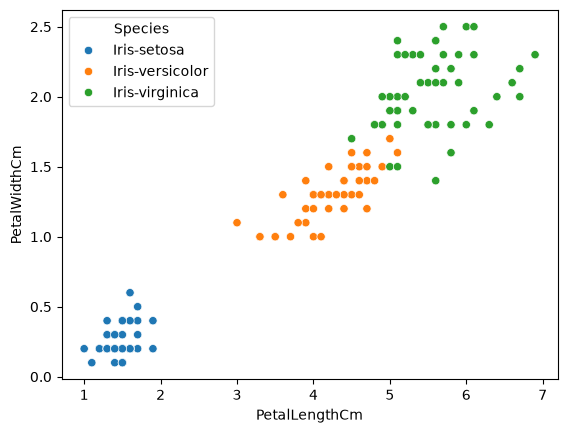

In [6]:
sns.scatterplot(x=df["PetalLengthCm"], y=df["PetalWidthCm"], hue = df["Species"])
plt.show()

In [7]:
df = df.drop("Id",axis=1)

In [8]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
X = df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]].values
y = df["Species"].values

In [10]:
y

<StringArray>
[   'Iris-setosa',    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',
    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',    'Iris-setosa',
    'Iris-setosa',    'Iris-setosa',
 ...
 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
 'Iris-virginica', 'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
 'Iris-virginica', 'Iris-virginica']
Length: 150, dtype: str

In [11]:
# label encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
le = LabelEncoder()
y = le.fit_transform(y)

In [14]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

In [17]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [18]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [19]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.long)
y_test =torch.tensor(y_test, dtype = torch.long)

In [20]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([120, 4]) torch.Size([30, 4])
torch.Size([120]) torch.Size([30])


In [21]:
from torch import nn

In [22]:
'''
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=4,out_features=16)
        self.layer2 = nn.Linear(in_features=16,out_features=16)
        self.layer3 = nn.Linear(in_features=16,out_features=3)

        self.relu = nn.ReLU()

    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
'''

'\nclass IrisClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.layer1 = nn.Linear(in_features=4,out_features=16)\n        self.layer2 = nn.Linear(in_features=16,out_features=16)\n        self.layer3 = nn.Linear(in_features=16,out_features=3)\n\n        self.relu = nn.ReLU()\n\n    def forward(self,x):\n        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))\n'

In [23]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer_stach = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,3)
        )

    def forward(self,x):
        return self.linear_layer_stach(x)
            

In [24]:
model = IrisClassifier()
loss_fn = nn.CrossEntropyLoss() # 2den fazla sınıf olduğu için

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [26]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = ( correct / len(y_pred))*100
    return acc

In [27]:
model(X_test)[:5].shape

torch.Size([5, 3])

In [28]:
y_logits = model(X_test)

In [29]:
y_pred_probs = torch.softmax(y_logits, dim = 1)

In [30]:
y_logits[:5]

tensor([[-0.4745,  0.2368,  0.0628],
        [-0.8852,  0.4161,  0.2865],
        [-0.6392,  0.3127,  0.2309],
        [-0.6468,  0.3178,  0.2408],
        [-0.4819,  0.2399,  0.0456]], grad_fn=<SliceBackward0>)

In [31]:
y_pred_probs[:5]

tensor([[0.2106, 0.4289, 0.3604],
        [0.1265, 0.4650, 0.4085],
        [0.1673, 0.4334, 0.3993],
        [0.1652, 0.4335, 0.4013],
        [0.2104, 0.4330, 0.3566]], grad_fn=<SliceBackward0>)

In [32]:
y_pred_probs[0]

tensor([0.2106, 0.4289, 0.3604], grad_fn=<SelectBackward0>)

In [33]:
torch.argmax(y_pred_probs[0])

tensor(1)

In [34]:
torch.sum(y_pred_probs[4])

tensor(1., grad_fn=<SumBackward0>)

In [35]:
y_pred_probs[0]

tensor([0.2106, 0.4289, 0.3604], grad_fn=<SelectBackward0>)

In [36]:
torch.softmax(y_logits, dim = 1).argmax(dim=1)

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1])

In [37]:
epochs = 200

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):

    model.train()

    logits = model(X_train)
    loss = loss_fn(logits,y_train)

    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = calculate_accuracy(y_train, pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
        test_acc = calculate_accuracy(y_test,test_pred)
    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 ==0:
        print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Epoch: 0, Loss: 1.08961820602417, Accuracy: 33.33333333333333, Test Loss: 1.0318049192428589, Test Accuracy: 33.33333333333333
Epoch: 20, Loss: 0.37626567482948303, Accuracy: 94.16666666666667, Test Loss: 0.36466047167778015, Test Accuracy: 96.66666666666667
Epoch: 40, Loss: 0.09420736134052277, Accuracy: 98.33333333333333, Test Loss: 0.10037685930728912, Test Accuracy: 100.0
Epoch: 60, Loss: 0.05701420456171036, Accuracy: 98.33333333333333, Test Loss: 0.055780328810214996, Test Accuracy: 100.0
Epoch: 80, Loss: 0.051705460995435715, Accuracy: 98.33333333333333, Test Loss: 0.045731257647275925, Test Accuracy: 100.0
Epoch: 100, Loss: 0.05104494094848633, Accuracy: 98.33333333333333, Test Loss: 0.04015554115176201, Test Accuracy: 100.0
Epoch: 120, Loss: 0.048115480691194534, Accuracy: 98.33333333333333, Test Loss: 0.04041071608662605, Test Accuracy: 100.0
Epoch: 140, Loss: 0.046800486743450165, Accuracy: 98.33333333333333, Test Loss: 0.04541540518403053, Test Accuracy: 100.0
Epoch: 160, L

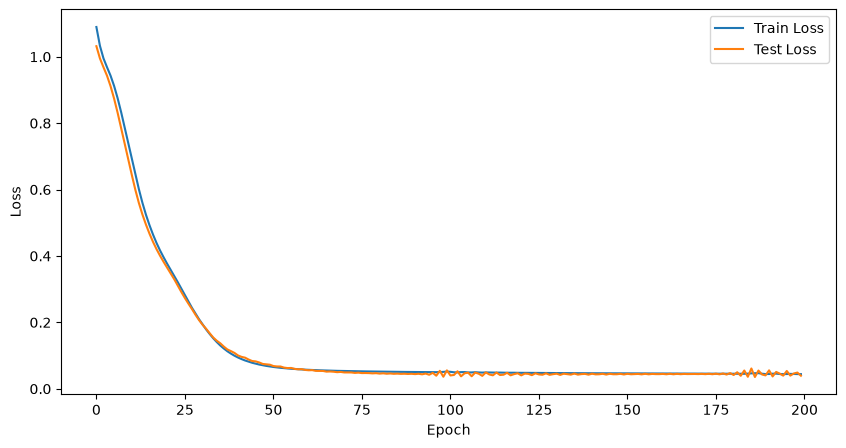

In [38]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label = "Train Loss")
plt.plot(test_losses, label = "Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

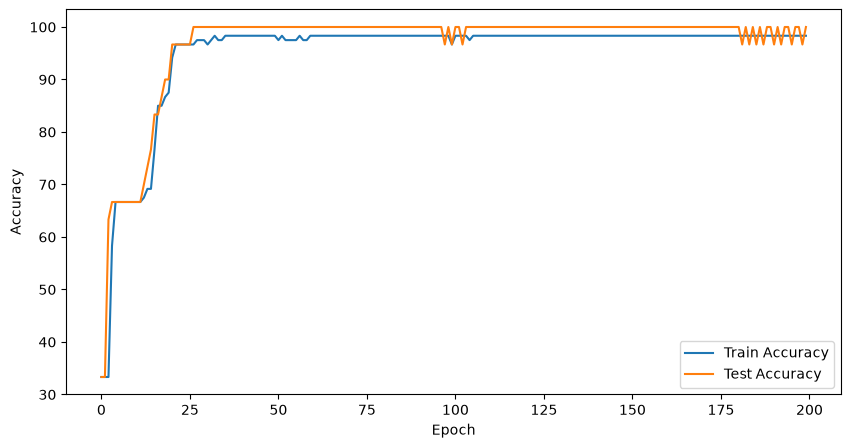

In [39]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label = "Train Accuracy")
plt.plot(test_accuracies, label = "Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [40]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [41]:
new_sample = np.array([[5.1,3.5,1.4,0.2]])

In [42]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [43]:
new_sample_tensor.shape

torch.Size([1, 4])

In [44]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits,dim=1)
    predicted_class = torch.argmax(probs,dim=1).item()

In [45]:
print(predicted_class)

0


In [46]:
le.inverse_transform([predicted_class])[0]

'Iris-setosa'

In [47]:
# torchmetrics

In [48]:
!pip install torchmetrics

In [49]:
from torchmetrics.classification import MulticlassAccuracy

In [50]:
accuracy = MulticlassAccuracy(num_classes=3)

In [51]:
epochs = 200

model2 = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model2.parameters(),lr=0.01)

for epoch in range(epochs):
    model2.train()
    logits = model2(X_train)
    loss = loss_fn(logits, y_train)

    pred = torch.softmax(logits, dim = 1).argmax(dim=1)
    acc = accuracy(pred,y_train).item()*100

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model2.eval()
    with torch.inference_mode():
        test_logits = model2(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_acc = accuracy(test_pred, y_test).item()*100

    if epoch % 20 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}")

Epoch: 0, Loss: 1.0902354717254639, Accuracy: 33.33333432674408, Test Loss: 1.0669054985046387, Test Accuracy: 33.33333432674408
Epoch: 20, Loss: 0.44354894757270813, Accuracy: 76.66666507720947, Test Loss: 0.4238010048866272, Test Accuracy: 83.33333730697632
Epoch: 40, Loss: 0.12382963299751282, Accuracy: 97.50000238418579, Test Loss: 0.12261022627353668, Test Accuracy: 100.0
Epoch: 60, Loss: 0.06255467981100082, Accuracy: 97.50000238418579, Test Loss: 0.04811783879995346, Test Accuracy: 100.0
Epoch: 80, Loss: 0.056070126593112946, Accuracy: 98.33333492279053, Test Loss: 0.03930829092860222, Test Accuracy: 100.0
Epoch: 100, Loss: 0.05291156470775604, Accuracy: 98.33333492279053, Test Loss: 0.04016602411866188, Test Accuracy: 100.0
Epoch: 120, Loss: 0.05055432766675949, Accuracy: 98.33333492279053, Test Loss: 0.041742123663425446, Test Accuracy: 100.0
Epoch: 140, Loss: 0.04862244054675102, Accuracy: 98.33333492279053, Test Loss: 0.04294150695204735, Test Accuracy: 100.0
Epoch: 160, Los

In [52]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [53]:
cm = MulticlassConfusionMatrix(num_classes=3)

In [54]:
matrix = cm(test_pred, y_test)

In [55]:
print(matrix)

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])


In [56]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

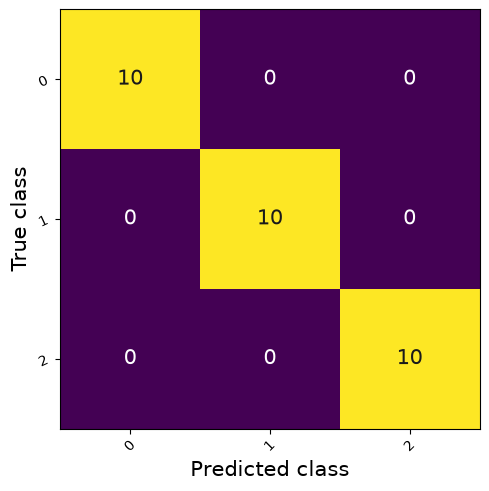

In [57]:
plot_confusion_matrix(matrix)

In [58]:
from pathlib import Path

In [64]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok = True)

MODEL_NAME = "iris_classification_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model2.state_dict(), f= MODEL_SAVE_PATH)

In [62]:
model2

IrisClassifier(
  (linear_layer_stach): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [63]:
model2.state_dict()

OrderedDict([('linear_layer_stach.0.weight',
              tensor([[ 0.2779,  0.6108, -0.6362, -0.7199],
                      [-0.1388, -0.4838,  0.1571, -0.0616],
                      [ 0.0154, -0.3072, -0.4327,  0.1816],
                      [ 0.1352,  0.4286, -0.2290, -0.8716],
                      [-0.2546,  0.2680,  0.0768, -0.2374],
                      [-0.0115, -0.1905, -0.2148, -0.0237],
                      [ 0.3036,  0.0868, -0.4555, -0.3277],
                      [-0.2539, -0.3038,  0.2316,  0.3364],
                      [ 0.3541,  0.4094, -0.3586, -0.7659],
                      [ 0.6658,  0.0318,  0.0603,  0.7646],
                      [-0.4576, -0.0834, -0.2548,  0.0659],
                      [-0.3907,  0.2544, -0.4042, -0.3593],
                      [ 0.0389,  0.0840,  0.8844,  0.5121],
                      [ 0.7066,  0.7403, -0.1073,  0.1597],
                      [-0.4095, -0.3373,  0.2409,  0.0246],
                      [ 0.1719, -0.2790,  0.0039, -0.09

In [65]:
loaded_model = IrisClassifier()

In [68]:
type(torch.load(MODEL_SAVE_PATH))

collections.OrderedDict

In [69]:
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [73]:
new_sample = np.array([[5.1,3.5,1.4,0.2]])
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)
loaded_model.eval()
with torch.inference_mode():
    logits = loaded_model(new_sample_tensor)
    probs = torch.softmax(logits, dim =1)
    predicted_class = torch.argmax(probs, dim = 1).item()
le.inverse_transform([predicted_class])[0]

'Iris-setosa'